In [53]:
import pandas as pd
df = pd.read_csv("Churn_Modelling.csv")


In [54]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [55]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [56]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [57]:
df = df.drop("RowNumber",axis = 1 )

In [58]:
df = df.drop(["Surname" , "CustomerId"],axis = 1 )

In [59]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [60]:
df.shape

(10000, 11)

In [61]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [62]:
df = pd.get_dummies(df,columns=["Geography"],dtype="int")

In [63]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])

In [64]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
def find_outliers(df,col):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.boxplot(df[col])
    plt.subplot(1,2,2)
    mean4=df[col].mean()
    std4=df[col].std() 
    sns.histplot(data=df , x=col , kde=True)
    plt.axvline(mean4,color="red")
    plt.axvline(mean4+3*std4 , color = "blue")
    plt.axvline(mean4-3*std4 , color="blue")

In [67]:
def show_outliers(df,col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr = q3-q1
    upper = q3+(1.5*iqr)
    lower=q1-(1.5*iqr)
    return df[(df[col]<lower) | (df[col]>upper)]
    

In [68]:
def handleOutliers(df,col):
    q1=df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr=q3-q1
    lower = q1-(1.5*iqr)
    upper = q3+(1.5*iqr)
    df.loc[df[col]>upper , col]=upper
    df.loc[df[col]<lower , col]=lower

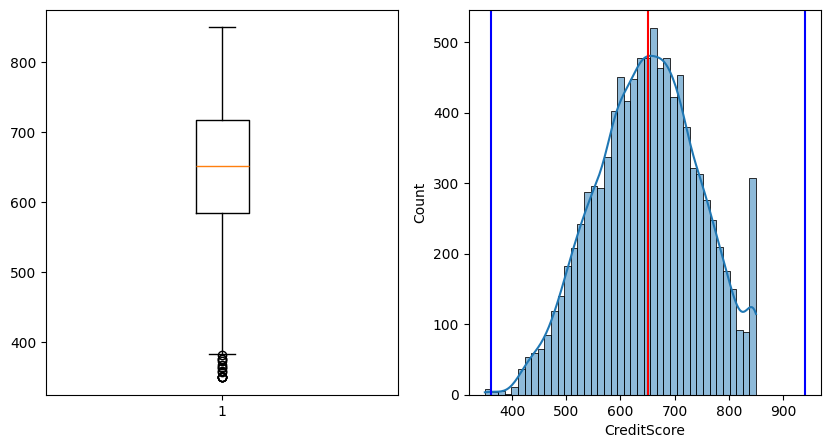

In [69]:
find_outliers(df,"CreditScore")

In [70]:
show_outliers(df,"CreditScore")

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
7,376,0,29,4,115046.74,4,1,0,119346.88,1,0,1,0
942,376,0,46,6,0.00,1,1,0,157333.69,1,1,0,0
1193,363,0,28,6,146098.43,3,1,0,100615.14,1,0,0,1
1405,359,0,44,6,128747.69,1,1,0,146955.71,1,1,0,0
1631,350,1,54,1,152677.48,1,1,1,191973.49,1,0,0,1
1838,350,1,39,0,109733.20,2,0,0,123602.11,1,0,1,0
1962,358,0,52,8,143542.36,3,1,0,141959.11,1,0,0,1
2473,351,0,57,4,163146.46,1,1,0,169621.69,1,0,1,0
2579,365,1,30,0,127760.07,1,1,0,81537.85,1,0,1,0
8154,367,1,42,6,93608.28,1,1,0,168816.73,1,0,0,1


In [71]:
handleOutliers(df,"CreditScore")

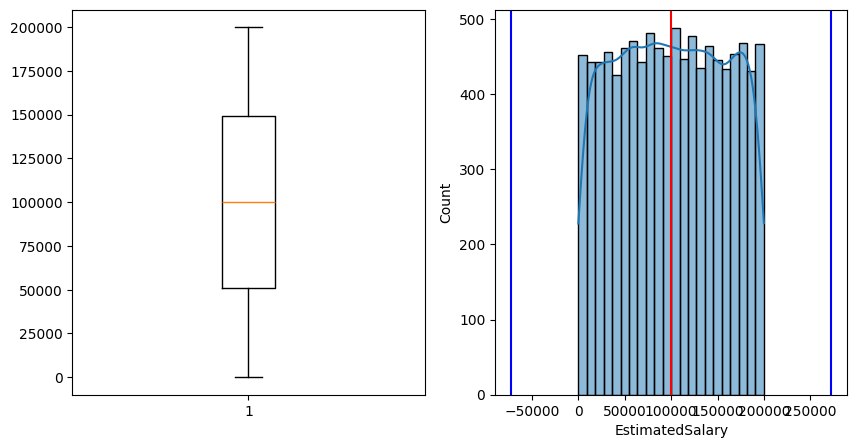

In [72]:
find_outliers(df,"EstimatedSalary")

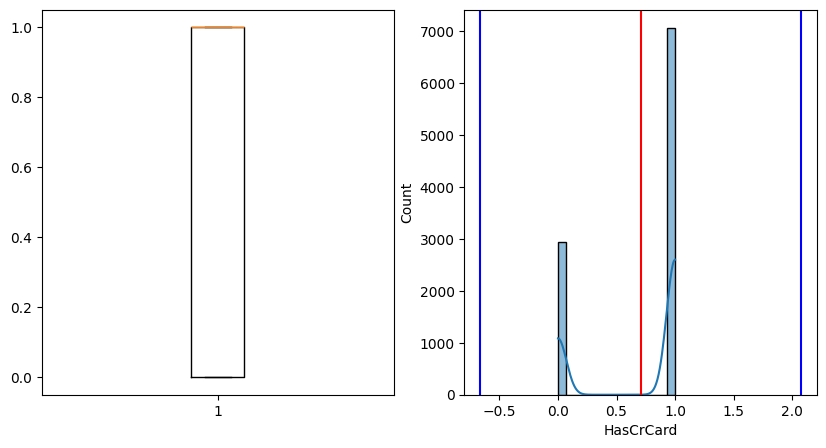

In [73]:
find_outliers(df,"HasCrCard")

In [74]:
show_outliers(df,"NumOfProducts")

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
7,383,0,29,4,115046.74,4,1,0,119346.88,1,0,1,0
70,738,1,58,2,133745.44,4,1,0,28373.86,1,0,1,0
1254,628,0,46,1,46870.43,4,1,0,31272.14,1,1,0,0
1469,819,0,49,1,120656.86,4,0,0,166164.30,1,0,1,0
1488,596,1,30,6,121345.88,4,1,0,41921.75,1,0,0,1
1701,792,1,50,9,0.00,4,1,1,194700.81,1,1,0,0
1876,640,1,39,9,131607.28,4,0,1,6981.43,1,0,1,0
2124,704,1,32,7,127785.17,4,0,0,184464.70,1,1,0,0
2196,773,1,47,2,118079.47,4,1,1,143007.49,1,0,1,0
2285,630,1,50,3,129370.91,4,1,1,47775.34,1,0,1,0


In [75]:
df.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.561300,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.501400,0.250900,0.247700
std,96.558702,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.500023,0.433553,0.431698
min,383.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,1.000000,0.000000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000,1.000000,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000,1.000000


In [76]:
x = df.drop("Exited" , axis = 1)
y = df["Exited"]

In [77]:
df.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.561300,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.501400,0.250900,0.247700
std,96.558702,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.500023,0.433553,0.431698
min,383.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,1.000000,0.000000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000,1.000000,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000,1.000000


In [48]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
x_sm,y_sm=sm.fit_resample(x,y)

In [78]:
y_sm.value_counts()

Exited
1    7963
0    7963
Name: count, dtype: int64

In [49]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [82]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_ss = ss.fit_transform(x_sm)

In [83]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [81]:
df.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.561300,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.501400,0.250900,0.247700
std,96.558702,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.500023,0.433553,0.431698
min,383.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,1.000000,0.000000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000,1.000000,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000,1.000000


In [105]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_ss,y_sm,test_size=0.2 , random_state=30)

In [91]:
# pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [106]:
import tensorflow.keras as tf

In [107]:
model = tf.models.Sequential()

In [108]:
model.add(tf.layers.Dense(12,activation = 'relu'))
model.add(tf.layers.Dense(6,activation = 'relu'))
model.add(tf.layers.Dense(1,activation ='sigmoid'))

In [111]:
model.compile(optimizer = "adam" ,loss="binary_crossentropy" , metrics=["accuracy"])



In [112]:
res=model.fit(x_train , y_train,epochs=10)

Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8442 - loss: 0.3431
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8480 - loss: 0.3372
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8509 - loss: 0.3323
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8546 - loss: 0.3279
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8564 - loss: 0.3234
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8575 - loss: 0.3202
Epoch 7/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8589 - loss: 0.3173
Epoch 8/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8598 - loss: 0.3155
Epoch 9/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8598 - loss: 0.3137
Epoch 10/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8600 - loss: 0.3131


In [113]:
# option 1 to check accuracy

test_pred = model.predict(x_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [114]:
pred_class=[]
for x in test_pred:
    if x < 0.5 :
        pred_class.append(0)

    else:
        pred_class.append(1)
        

In [115]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , pred_class)

0.8531073446327684

In [116]:
# option 2

In [117]:
model.evaluate(x_test , y_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8531 - loss: 0.3282


[0.3281676173210144, 0.8531073331832886]